In [1]:
import hashlib
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

warnings.filterwarnings('ignore')

REPO_ROOT  = Path('C:/Users/Lenovo/Documents/TRADING-BOT')
DATA_FILE  = REPO_ROOT / 'data' / 'raw' / 'BTCUSDT_M1.csv'
OUTPUT_DIR = REPO_ROOT / 'research' / 'experiments' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Study configuration (lenses, not optimization targets) ─────────────────────
ATR_WINDOW          = 20      # M1 candles — ~20 min baseline
PERCENTILE_WINDOW   = 500     # M1 candles — ~8h rolling window for P95 shock
COMPRESSION_WINDOW  = 10      # M1 candles — pre-burst compression lookback (< ATR_WINDOW to create variance)
ATR_THRESHOLDS      = [1.5, 2.0, 2.5, 3.0]
EER_HIGH            = 0.65    # |close-open|/(high-low) >= 0.65 → directional
EER_LOW             = 0.40    # < 0.40 → noisy/two-sided
VOL_HIGH_PCT        = 0.90    # top 10% volume → high participation
VOL_LOW_PCT         = 0.50    # bottom 50% → low participation
COMPRESSION_THRESH  = 0.80    # pre_compression < 0.80 → compressed state
FWD_HORIZONS        = [1, 3, 5, 10, 20]
TAIL_THRESHOLDS_PCT = [0.0010, 0.0015, 0.0020]  # 0.10%, 0.15%, 0.20%
COSTS_TOTAL         = 0.0008  # 2x taker 0.04% — reference only
SPLIT_DATE          = pd.Timestamp('2026-03-29', tz='UTC')

SPEC = {
    'version': '07-volatility-expansion-study-v1',
    'hypothesis': (
        'After a True Range expansion event (TR/ATR > threshold), posterior '
        'N-candle directional persistence varies systematically with '
        'Expansion Efficiency Ratio (EER=|C-O|/(H-L)), volume participation, '
        'and pre-burst compression state.'
    ),
    'measurement_type': 'structure_study_only',
    'dbct_note': (
        'DBCT (Dynamic Benchmark Contamination Test) not required: TR/ATR '
        'is a ratio of raw price ranges — no external dynamic benchmark '
        'contaminates the signal definition. Any edge found here would not '
        'be an artifact of benchmark drift mechanics.'
    ),
    'dataset': 'BTCUSDT_M1.csv',
    'all_24h_candles': True,
    'train_only': True,
    'params': {
        'ATR_WINDOW': ATR_WINDOW,
        'PERCENTILE_WINDOW': PERCENTILE_WINDOW,
        'COMPRESSION_WINDOW': COMPRESSION_WINDOW,
        'ATR_THRESHOLDS': ATR_THRESHOLDS,
        'EER_HIGH': EER_HIGH,
        'EER_LOW': EER_LOW,
        'VOL_HIGH_PCT': VOL_HIGH_PCT,
        'VOL_LOW_PCT': VOL_LOW_PCT,
        'FWD_HORIZONS': FWD_HORIZONS,
        'TAIL_THRESHOLDS_PCT': TAIL_THRESHOLDS_PCT,
    }
}
SPEC_HASH = hashlib.sha256(
    json.dumps(SPEC, sort_keys=True).encode()
).hexdigest()[:12]

print('Cell 1 OK — Exp 07: Volatility Expansion Asymmetry Study')
print(f'SPEC_HASH: {SPEC_HASH}')
print('TRAIN ONLY — holdout untouched')
print()
print('Mandatory measurements:')
for m in [
    'A. Continuation half-life curves (EER / Volume / Compression conditioned)',
    'B. Continuation magnitude — direction alone is not enough',
    'C. Tail persistence P(|move|>0.10%, 0.15%, 0.20%)',
    'D. Failure asymmetry — reversal violence when continuation fails',
    'E. Post-expansion volatility persistence decay',
    'F. EER x Volume 2D interaction heatmap (key structural question)',
    'G. Pre-burst compression state analysis',
]:
    print(f'  {m}')

Cell 1 OK — Exp 07: Volatility Expansion Asymmetry Study
SPEC_HASH: c4eea0bd7574
TRAIN ONLY — holdout untouched

Mandatory measurements:
  A. Continuation half-life curves (EER / Volume / Compression conditioned)
  B. Continuation magnitude — direction alone is not enough
  C. Tail persistence P(|move|>0.10%, 0.15%, 0.20%)
  D. Failure asymmetry — reversal violence when continuation fails
  E. Post-expansion volatility persistence decay
  F. EER x Volume 2D interaction heatmap (key structural question)
  G. Pre-burst compression state analysis


In [2]:
# ── Load full M1 dataset + all features ────────────────────────────────────────
df_raw = pd.read_csv(DATA_FILE)
df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='ms', utc=True)
df_raw = df_raw.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_raw[col] = df_raw[col].astype(float)
df_raw['date'] = df_raw['open_time'].dt.date

print(f'Loaded: {len(df_raw):,} M1 candles')
print(f'Range:  {df_raw["open_time"].iloc[0].date()} → {df_raw["open_time"].iloc[-1].date()}')

# ── True Range + ATR ──────────────────────────────────────────────────────────
prev_close   = df_raw['close'].shift(1)
df_raw['tr'] = np.maximum(
    df_raw['high'] - df_raw['low'],
    np.maximum(
        (df_raw['high'] - prev_close).abs(),
        (df_raw['low']  - prev_close).abs()
    )
)
df_raw['atr']          = df_raw['tr'].rolling(ATR_WINDOW, min_periods=ATR_WINDOW // 2).mean()
df_raw['tr_atr_ratio'] = df_raw['tr'] / df_raw['atr']

# ── Percentile shock: TR > P95 of rolling PERCENTILE_WINDOW ──────────────────
df_raw['tr_p95']       = df_raw['tr'].rolling(PERCENTILE_WINDOW, min_periods=50).quantile(0.95)
df_raw['is_p95_shock'] = (df_raw['tr'] > df_raw['tr_p95']).astype(int)

# ── Expansion Efficiency Ratio: EER = |close - open| / (high - low) ───────────
# EER → 1.0: directional initiative flow (clean displacement)
# EER → 0.0: two-sided auction (noise, long wicks, absorption)
body            = (df_raw['close'] - df_raw['open']).abs()
candle_range    = (df_raw['high'] - df_raw['low']).replace(0, np.nan)
df_raw['eer']   = (body / candle_range).clip(0, 1)

# ── Burst direction ────────────────────────────────────────────────────────────
df_raw['burst_dir'] = np.where(df_raw['close'] >= df_raw['open'], 'BULL', 'BEAR')
df_raw['dir_sign']  = np.where(df_raw['close'] >= df_raw['open'], 1.0, -1.0)

# ── Volume percentile (rolling) ────────────────────────────────────────────────
df_raw['vol_pct'] = (
    df_raw['volume']
    .rolling(PERCENTILE_WINDOW, min_periods=50)
    .rank(pct=True)
)

# ── Pre-burst compression state ────────────────────────────────────────────────
# .shift(1) ensures we measure the N candles BEFORE the burst candle itself.
# COMPRESSION_WINDOW < ATR_WINDOW so ratio has real variance (tight recent vs longer baseline).
# ratio < COMPRESSION_THRESH → compressed (tight range before expansion = energy stored)
df_raw['pre_compression'] = (
    df_raw['tr'].rolling(COMPRESSION_WINDOW, min_periods=COMPRESSION_WINDOW // 2).mean().shift(1)
    / df_raw['atr'].shift(1)
)
df_raw['is_compressed'] = (df_raw['pre_compression'] < COMPRESSION_THRESH).astype(int)

# ── Realized volatility proxy (backward-looking, no leakage) ──────────────────
df_raw['ret'] = df_raw['close'].pct_change()
df_raw['rv5'] = df_raw['ret'].rolling(5, min_periods=3).std()

# ── Session tag (metadata only — not a filter) ─────────────────────────────────
_hour = df_raw['open_time'].dt.hour
df_raw['session'] = pd.cut(
    _hour,
    bins=[-1, 7, 11, 15, 19, 24],
    labels=['Asia', 'London', 'Overlap', 'NY', 'Off']
)

# ── EER bucket ────────────────────────────────────────────────────────────────
df_raw['eer_bucket'] = pd.cut(
    df_raw['eer'],
    bins=[-0.01, EER_LOW, EER_HIGH, 1.01],
    labels=['Low', 'Med', 'High']
)

# ── Volume bucket ─────────────────────────────────────────────────────────────
df_raw['vol_bucket'] = pd.cut(
    df_raw['vol_pct'],
    bins=[-0.01, VOL_LOW_PCT, VOL_HIGH_PCT, 1.01],
    labels=['Low', 'Med', 'High']
)

atr_pct = (df_raw['atr'] / df_raw['close']).median() * 100
print(f'\nATR median: {df_raw["atr"].median():.4f} USDT  ({atr_pct:.4f}% of price)')
print(f'is_p95_shock rate:  {df_raw["is_p95_shock"].mean()*100:.1f}% of candles')
print(f'is_compressed rate: {df_raw["is_compressed"].mean()*100:.1f}% of candles')
print()
print('EER distribution (all candles):')
print(df_raw['eer_bucket'].value_counts(normalize=True).mul(100).round(1))
print('Cell 2 OK')

Loaded: 518,401 M1 candles
Range:  2025-05-29 → 2026-05-24

ATR median: 41.7775 USDT  (0.0448% of price)
is_p95_shock rate:  5.9% of candles
is_compressed rate: 16.1% of candles

EER distribution (all candles):
eer_bucket
High    57.5
Low     25.3
Med     17.3
Name: proportion, dtype: float64
Cell 2 OK


In [3]:
# ── Forward columns (within-day only via groupby date) ─────────────────────────
MAX_HORIZON = max(FWD_HORIZONS)

print(f'Computing forward close columns (1..{MAX_HORIZON})...')
for h in range(1, MAX_HORIZON + 1):
    df_raw[f'fwd_c{h}'] = df_raw.groupby('date')['close'].shift(-h)

print(f'Computing forward rv5 columns (1..{MAX_HORIZON})...')
for h in range(1, MAX_HORIZON + 1):
    df_raw[f'fwd_rv5_{h}c'] = df_raw.groupby('date')['rv5'].shift(-h)

# Direction-signed continuation return:
# positive = price moved in burst direction at horizon N
for h in FWD_HORIZONS:
    df_raw[f'cont_ret_{h}c'] = (
        (df_raw[f'fwd_c{h}'] - df_raw['close'])
        * df_raw['dir_sign']
        / df_raw['close']
    )

# MFE and MAE over MAX_HORIZON (vectorized)
fav_cols = [
    (df_raw[f'fwd_c{h}'] - df_raw['close']) * df_raw['dir_sign'] / df_raw['close']
    for h in range(1, MAX_HORIZON + 1)
]
adv_cols = [
    -(df_raw[f'fwd_c{h}'] - df_raw['close']) * df_raw['dir_sign'] / df_raw['close']
    for h in range(1, MAX_HORIZON + 1)
]
df_raw['mfe_20c'] = pd.concat(fav_cols, axis=1).max(axis=1)
df_raw['mae_20c'] = pd.concat(adv_cols, axis=1).max(axis=1)

# ── Train / holdout split (holdout NEVER touched) ─────────────────────────────
df_raw['split'] = 'holdout'
df_raw.loc[df_raw['open_time'] < SPLIT_DATE, 'split'] = 'train'

train = df_raw[df_raw['split'] == 'train'].copy()
n_days = train['date'].nunique()

print(f'\nTRAIN: {len(train):,} candles | {n_days:,} days')
print(f'       {train["open_time"].iloc[0].date()} → {train["open_time"].iloc[-1].date()}')
print('Cell 3 OK')

Computing forward close columns (1..20)...
Computing forward rv5 columns (1..20)...

TRAIN: 436,428 candles | 304 days
       2025-05-29 → 2026-03-28
Cell 3 OK


In [4]:
# ── Burst event characterization ──────────────────────────────────────────────
print('Burst event counts (train, all 24h candles):')
print(f'{"Threshold":>10}  {"n_events":>10}  {"events/day":>12}  {"P95_overlap%":>14}')
for T in ATR_THRESHOLDS:
    ev = train[train['tr_atr_ratio'] > T]
    p95_ol = (ev['is_p95_shock'] == 1).mean() * 100
    print(f'{T:>10.1f}  {len(ev):>10,}  {len(ev)/n_days:>12.1f}  {p95_ol:>14.1f}%')

p95_n = (train['is_p95_shock'] == 1).sum()
print(f'\nP95 shock (TR > rolling P95): {p95_n:,}  ({p95_n/n_days:.1f}/day)')
print()

T_REF = 2.0
ev20  = train[train['tr_atr_ratio'] > T_REF]
print(f'Burst anatomy (TR/ATR > {T_REF}, n={len(ev20):,}):')
print(f'  EER bucket:'); print(ev20['eer_bucket'].value_counts(normalize=True).mul(100).round(1))
print(f'  Volume bucket:'); print(ev20['vol_bucket'].value_counts(normalize=True).mul(100).round(1))
print(f'  Direction: BULL={( ev20["burst_dir"]=="BULL").mean()*100:.1f}%  BEAR={(ev20["burst_dir"]=="BEAR").mean()*100:.1f}%')
print(f'  Compressed: {ev20["is_compressed"].mean()*100:.1f}%  |  Not compressed: {(1-ev20["is_compressed"]).mean()*100:.1f}%')
print(f'  EER mean: {ev20["eer"].mean():.3f}  |  overall mean: {train["eer"].mean():.3f}')
print()
print('Session distribution (train, TR/ATR > 2.0):')
print(ev20['session'].value_counts(normalize=True).mul(100).round(1))
print('Cell 4 OK')

Burst event counts (train, all 24h candles):
 Threshold    n_events    events/day    P95_overlap%
       1.5      79,981         263.1            24.1%
       2.0      37,681         124.0            35.5%
       2.5      19,435          63.9            45.2%
       3.0      10,818          35.6            52.3%

P95 shock (TR > rolling P95): 25,737  (84.7/day)

Burst anatomy (TR/ATR > 2.0, n=37,681):
  EER bucket:
eer_bucket
High    76.2
Med     14.3
Low      9.5
Name: proportion, dtype: float64
  Volume bucket:
vol_bucket
Med     47.3
High    36.6
Low     16.0
Name: proportion, dtype: float64
  Direction: BULL=49.2%  BEAR=50.8%
  Compressed: 16.3%  |  Not compressed: 83.7%
  EER mean: 0.798  |  overall mean: 0.662

Session distribution (train, TR/ATR > 2.0):
session
Asia       34.8
London     18.3
Off        17.7
Overlap    16.1
NY         13.1
Name: proportion, dtype: float64
Cell 4 OK


In [5]:
# ── QUESTION A: Continuation half-life curves ─────────────────────────────────
# P(cont at horizon N) = P(cont_ret_Nc > 0) = price moved in burst direction
SEP = '=' * 65
print(SEP)
print('QUESTION A: Continuation half-life curves (train only)')
print('P(price continued in burst direction at horizon N)')
print(SEP)

T_REF   = 2.0
req_cols = [f'cont_ret_{h}c' for h in FWD_HORIZONS]
ev = train[train['tr_atr_ratio'] > T_REF].dropna(subset=req_cols)

def p_cont_row(subset, label, width=26):
    vals = []
    for h in FWD_HORIZONS:
        col = f'cont_ret_{h}c'
        sub = subset[col].dropna()
        vals.append(sub.gt(0).mean() * 100 if len(sub) > 5 else float('nan'))
    print(f'  {label:<{width}}' + ''.join(f'  {v:>5.1f}%' for v in vals))

header = f'  {"Group":<26}' + ''.join(f'  {h:>5}c' for h in FWD_HORIZONS)
print(header)
print('  ' + '-'*60)
p_cont_row(ev, f'All bursts (n={len(ev):,})')

print()
print('  By EER bucket:')
for eer_b in ['High', 'Med', 'Low']:
    sub = ev[ev['eer_bucket'] == eer_b]
    if len(sub) >= 20:
        p_cont_row(sub, f'    EER={eer_b} (n={len(sub):,})')

print()
print('  By Volume bucket:')
for vol_b in ['High', 'Med', 'Low']:
    sub = ev[ev['vol_bucket'] == vol_b]
    if len(sub) >= 20:
        p_cont_row(sub, f'    Vol={vol_b} (n={len(sub):,})')

print()
print('  By pre-burst compression:')
for comp, comp_label in [(1, 'Compressed'), (0, 'Not compressed')]:
    sub = ev[ev['is_compressed'] == comp]
    if len(sub) >= 20:
        p_cont_row(sub, f'    {comp_label} (n={len(sub):,})')

print()
print('  By burst direction:')
for bd in ['BULL', 'BEAR']:
    sub = ev[ev['burst_dir'] == bd]
    if len(sub) >= 20:
        p_cont_row(sub, f'    {bd} (n={len(sub):,})')

print()
print('  EER=High + Vol=High (best bin):')
best = ev[(ev['eer_bucket'] == 'High') & (ev['vol_bucket'] == 'High')]
if len(best) >= 20:
    p_cont_row(best, f'    EER=H+Vol=H (n={len(best):,})')

print()
print('  t-test: mean(cont_ret) > 0?')
for h in FWD_HORIZONS:
    col  = f'cont_ret_{h}c'
    sub  = ev[col].dropna()
    tstat, pval = stats.ttest_1samp(sub, 0, alternative='greater')
    sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else 'ns')
    print(f'    {h:>2}c: mean={sub.mean()*100:+.5f}%  p={pval:.4f}  {sig}')
print('Cell 5 OK')

QUESTION A: Continuation half-life curves (train only)
P(price continued in burst direction at horizon N)
  Group                           1c      3c      5c     10c     20c
  ------------------------------------------------------------
  All bursts (n=37,227)        47.2%   48.3%   48.6%   48.5%   48.0%

  By EER bucket:
      EER=High (n=28,360)      47.3%   48.5%   48.8%   48.7%   48.1%
      EER=Med (n=5,329)        46.3%   46.9%   47.8%   47.4%   46.9%
      EER=Low (n=3,538)        47.9%   48.7%   48.1%   48.8%   48.4%

  By Volume bucket:
      Vol=High (n=13,680)      45.5%   45.8%   46.5%   45.9%   45.7%
      Vol=Med (n=17,610)       47.6%   48.9%   49.2%   49.6%   49.0%
      Vol=Low (n=5,933)        50.0%   51.9%   51.4%   51.6%   50.1%

  By pre-burst compression:
      Compressed (n=6,037)     47.1%   49.4%   50.1%   50.1%   48.8%
      Not compressed (n=31,190)   47.2%   48.0%   48.3%   48.2%   47.8%

  By burst direction:
      BULL (n=18,321)          47.6%   48.8%   

In [6]:
# ── QUESTION B: Continuation magnitude ────────────────────────────────────────
# Direction probability alone does not make a tradeable edge.
# The move must exceed taker costs.
print(SEP)
print('QUESTION B: Continuation magnitude')
print(f'Taker cost reference: {COSTS_TOTAL*100:.3f}% (2x 0.04%)')
print(SEP)

T_REF = 2.0
ev    = train[train['tr_atr_ratio'] > T_REF].dropna(subset=[f'cont_ret_{h}c' for h in FWD_HORIZONS])

groups = [
    ('All',         ev),
    ('EER=High',    ev[ev['eer_bucket'] == 'High']),
    ('EER=Low',     ev[ev['eer_bucket'] == 'Low']),
    ('Vol=High',    ev[ev['vol_bucket'] == 'High']),
    ('Vol=Low',     ev[ev['vol_bucket'] == 'Low']),
    ('Compressed',  ev[ev['is_compressed'] == 1]),
    ('EER=H+Vol=H', ev[(ev['eer_bucket']=='High') & (ev['vol_bucket']=='High')]),
]

mag_rows = []
for label, subset in groups:
    if len(subset) < 20: continue
    row = {'label': label, 'n': len(subset)}
    for h in FWD_HORIZONS:
        col = f'cont_ret_{h}c'
        sub = subset[col].dropna()
        row[f'p50_all_{h}c']     = sub.median() * 100
        row[f'p_beat_cost_{h}c'] = (sub > COSTS_TOTAL).mean() * 100
    mag_rows.append(row)

mdf = pd.DataFrame(mag_rows)

print('Median directional drift at each horizon [%] (positive = continuation):')
print(f'  {"Group":<14}  {"n":>6}' + ''.join(f'  {h:>5}c' for h in FWD_HORIZONS))
for _, row in mdf.iterrows():
    print(f'  {row["label"]:<14}  {int(row["n"]):>6}'
          + ''.join(f'  {row[f"p50_all_{h}c"]:>+5.4f}' for h in FWD_HORIZONS))

print()
print(f'P(directional move > taker cost {COSTS_TOTAL*100:.3f}%) [%]:')
print(f'  {"Group":<14}  {"n":>6}' + ''.join(f'  {h:>5}c' for h in FWD_HORIZONS))
for _, row in mdf.iterrows():
    print(f'  {row["label"]:<14}  {int(row["n"]):>6}'
          + ''.join(f'  {row[f"p_beat_cost_{h}c"]:>5.1f}%' for h in FWD_HORIZONS))

mdf.to_csv(OUTPUT_DIR / '07_magnitude.csv', index=False)
print('\nSaved: 07_magnitude.csv')
print('Cell 6 OK')

QUESTION B: Continuation magnitude
Taker cost reference: 0.080% (2x 0.04%)
Median directional drift at each horizon [%] (positive = continuation):
  Group                n      1c      3c      5c     10c     20c
  All              37227  +0.0000  -0.0003  -0.0015  -0.0030  -0.0060
  EER=High         28360  +0.0000  -0.0000  -0.0008  -0.0022  -0.0052
  EER=Low           3538  +0.0000  -0.0008  -0.0031  -0.0035  -0.0055
  Vol=High         13680  -0.0017  -0.0061  -0.0075  -0.0112  -0.0157
  Vol=Low           5933  +0.0000  +0.0012  +0.0014  +0.0037  +0.0003
  Compressed        6037  +0.0000  +0.0000  +0.0000  +0.0002  -0.0026
  EER=H+Vol=H       8930  -0.0024  -0.0064  -0.0074  -0.0126  -0.0169

P(directional move > taker cost 0.080%) [%]:
  Group                n      1c      3c      5c     10c     20c
  All              37227    6.7%   12.6%   15.9%   21.4%   26.5%
  EER=High         28360    6.0%   11.7%   14.8%   20.3%   25.7%
  EER=Low           3538    9.0%   15.8%   19.7%   25.5% 

In [7]:
# ── QUESTION C: Tail persistence ──────────────────────────────────────────────
# Tradeable edge requires sufficient magnitude, not just direction.
# Measure P(cont_ret > X%) for X = 0.10%, 0.15%, 0.20%
print(SEP)
print('QUESTION C: Tail persistence — P(directional move > X%)')
print('If P(move > costs) << 50%: direction is irrelevant, costs dominate')
print(SEP)

T_REF = 2.0
ev    = train[train['tr_atr_ratio'] > T_REF].dropna(subset=[f'cont_ret_{h}c' for h in FWD_HORIZONS])

groups = [
    ('All',         ev),
    ('EER=High',    ev[ev['eer_bucket'] == 'High']),
    ('EER=Low',     ev[ev['eer_bucket'] == 'Low']),
    ('Vol=High',    ev[ev['vol_bucket'] == 'High']),
    ('Compressed',  ev[ev['is_compressed'] == 1]),
    ('EER=H+Vol=H', ev[(ev['eer_bucket']=='High') & (ev['vol_bucket']=='High')]),
]

for tail_t in TAIL_THRESHOLDS_PCT:
    print(f'P(cont_ret > {tail_t*100:.2f}%) [%]:')
    print(f'  {"Group":<14}  {"n":>6}' + ''.join(f'  {h:>5}c' for h in FWD_HORIZONS))
    for label, subset in groups:
        if len(subset) < 20: continue
        vals = [(subset[f'cont_ret_{h}c'].dropna() > tail_t).mean() * 100 for h in FWD_HORIZONS]
        print(f'  {label:<14}  {len(subset):>6}' + ''.join(f'  {v:>5.1f}%' for v in vals))
    print()

print('Cell 7 OK')

QUESTION C: Tail persistence — P(directional move > X%)
If P(move > costs) << 50%: direction is irrelevant, costs dominate
P(cont_ret > 0.10%) [%]:
  Group                n      1c      3c      5c     10c     20c
  All              37227    4.6%    9.5%   12.4%   17.5%   22.7%
  EER=High         28360    4.1%    8.7%   11.5%   16.5%   21.8%
  EER=Low           3538    6.2%   12.4%   16.1%   20.9%   26.4%
  Vol=High         13680    8.0%   13.4%   16.4%   21.4%   25.5%
  Compressed        6037    2.0%    4.9%    7.7%   12.3%   17.7%
  EER=H+Vol=H       8930    7.4%   12.7%   15.6%   20.2%   24.5%

P(cont_ret > 0.15%) [%]:
  Group                n      1c      3c      5c     10c     20c
  All              37227    2.1%    5.3%    7.2%   11.2%   15.6%
  EER=High         28360    2.0%    4.8%    6.5%   10.3%   14.6%
  EER=Low           3538    2.5%    6.6%    9.9%   14.0%   19.1%
  Vol=High         13680    4.1%    8.6%   10.9%   15.4%   19.4%
  Compressed        6037    0.8%    2.2%    3.

In [8]:
# ── QUESTION D: Failure asymmetry ─────────────────────────────────────────────
# When continuation fails: how violent is the reversal?
# E_net = P(cont) * avg_gain + P(fail) * avg_loss
print(SEP)
print('QUESTION D: Failure asymmetry')
print('E_net = P(cont) * avg_gain + P(fail) * avg_loss')
print(SEP)

T_REF = 2.0
ev    = train[train['tr_atr_ratio'] > T_REF].dropna(subset=[f'cont_ret_{h}c' for h in FWD_HORIZONS])

groups = [
    ('All',         ev),
    ('EER=High',    ev[ev['eer_bucket'] == 'High']),
    ('EER=Low',     ev[ev['eer_bucket'] == 'Low']),
    ('Vol=High',    ev[ev['vol_bucket'] == 'High']),
    ('Compressed',  ev[ev['is_compressed'] == 1]),
    ('EER=H+Vol=H', ev[(ev['eer_bucket']=='High') & (ev['vol_bucket']=='High')]),
]

asym_rows = []
for label, subset in groups:
    if len(subset) < 20: continue
    row = {'label': label, 'n': len(subset)}
    for h in FWD_HORIZONS:
        col = f'cont_ret_{h}c'
        s   = subset[col].dropna()
        cm  = s > 0
        fm  = s <= 0
        p_c = cm.mean()
        p_f = fm.mean()
        avg_c = s[cm].mean() * 100 if cm.sum() > 0 else 0.0
        avg_f = s[fm].mean() * 100 if fm.sum() > 0 else 0.0
        e_net = p_c * avg_c + p_f * avg_f
        row[f'p_cont_{h}c']   = round(p_c * 100, 1)
        row[f'avg_gain_{h}c'] = round(avg_c, 5)
        row[f'avg_loss_{h}c'] = round(avg_f, 5)
        row[f'e_net_{h}c']    = round(e_net, 5)
    asym_rows.append(row)

adf = pd.DataFrame(asym_rows)

for h in FWD_HORIZONS:
    print(f'\nHorizon {h}c:')
    print(f'  {"Group":<14}  {"n":>6}  {"P(cont)%":>9}  {"avg_gain%":>10}  {"avg_loss%":>10}  {"E_net%":>8}')
    for _, row in adf.iterrows():
        print(f'  {row["label"]:<14}  {int(row["n"]):>6}  '
              f'{row[f"p_cont_{h}c"]:>9.1f}  '
              f'{row[f"avg_gain_{h}c"]:>+10.5f}  '
              f'{row[f"avg_loss_{h}c"]:>+10.5f}  '
              f'{row[f"e_net_{h}c"]:>+8.5f}')

adf.to_csv(OUTPUT_DIR / '07_asymmetry.csv', index=False)
print('\nSaved: 07_asymmetry.csv')
print('Cell 8 OK')

QUESTION D: Failure asymmetry
E_net = P(cont) * avg_gain + P(fail) * avg_loss

Horizon 1c:
  Group                n   P(cont)%   avg_gain%   avg_loss%    E_net%
  All              37227       47.2    +0.04300    -0.03876  -0.00016
  EER=High         28360       47.3    +0.04028    -0.03577  +0.00020
  EER=Low           3538       47.9    +0.05196    -0.05247  -0.00241
  Vol=High         13680       45.5    +0.06216    -0.05608  -0.00223
  Compressed        6037       47.1    +0.02830    -0.02445  +0.00039
  EER=H+Vol=H       8930       44.4    +0.06079    -0.05340  -0.00264

Horizon 3c:
  Group                n   P(cont)%   avg_gain%   avg_loss%    E_net%
  All              37227       48.3    +0.07029    -0.06389  +0.00087
  EER=High         28360       48.5    +0.06613    -0.05910  +0.00158
  EER=Low           3538       48.7    +0.08484    -0.08414  -0.00180
  Vol=High         13680       45.8    +0.09922    -0.08678  -0.00161
  Compressed        6037       49.4    +0.04693    -0.04

In [9]:
# ── QUESTION E: Post-expansion volatility persistence decay ────────────────────
# After burst: does realized vol persist (true momentum) or collapse (exhaustion)?
# rv_ratio = rv5_{t+N} / rv5_t
#   > 1.0: volatility persisted → consistent with continuation regime
#   < 1.0: volatility collapsed → consistent with one-off exhaustion event
print(SEP)
print('QUESTION E: Post-expansion volatility persistence decay')
print('rv_ratio = realized_vol_t+N / realized_vol_t')
print('> 1.0 = vol persisted (momentum)  |  < 1.0 = vol collapsed (exhaustion)')
print(SEP)

T_REF    = 2.0
fwd_rv   = [f'fwd_rv5_{h}c' for h in FWD_HORIZONS]
ev       = train[train['tr_atr_ratio'] > T_REF].copy()
ev_valid = ev.dropna(subset=['rv5'] + fwd_rv)

groups = [
    ('All',         ev_valid),
    ('EER=High',    ev_valid[ev_valid['eer_bucket'] == 'High']),
    ('EER=Low',     ev_valid[ev_valid['eer_bucket'] == 'Low']),
    ('Vol=High',    ev_valid[ev_valid['vol_bucket'] == 'High']),
    ('Compressed',  ev_valid[ev_valid['is_compressed'] == 1]),
]

rv_rows = []
for label, subset in groups:
    if len(subset) < 20: continue
    rv_t = subset['rv5'].clip(lower=1e-10)
    row  = {'label': label, 'n': len(subset)}
    for h in FWD_HORIZONS:
        fc   = f'fwd_rv5_{h}c'
        ratio = (subset[fc] / rv_t).dropna()
        row[f'rv_p50_{h}c']     = round(ratio.median(), 4)
        row[f'rv_p75_{h}c']     = round(ratio.quantile(0.75), 4)
        row[f'pct_persist_{h}c'] = round((ratio > 0.80).mean() * 100, 1)
    rv_rows.append(row)

rvdf = pd.DataFrame(rv_rows)

print('Median rv_ratio (rv_t+N / rv_t)  [>1 = vol persists, <1 = collapsed]:')
print(f'  {"Group":<14}  {"n":>6}' + ''.join(f'  {h:>5}c' for h in FWD_HORIZONS))
for _, row in rvdf.iterrows():
    print(f'  {row["label"]:<14}  {int(row["n"]):>6}'
          + ''.join(f'  {row[f"rv_p50_{h}c"]:>5.3f}' for h in FWD_HORIZONS))

print()
print('P(rv_t+N > 80% of rv_t) [%]  — vol persistence rate:')
print(f'  {"Group":<14}  {"n":>6}' + ''.join(f'  {h:>5}c' for h in FWD_HORIZONS))
for _, row in rvdf.iterrows():
    print(f'  {row["label"]:<14}  {int(row["n"]):>6}'
          + ''.join(f'  {row[f"pct_persist_{h}c"]:>5.1f}%' for h in FWD_HORIZONS))

rvdf.to_csv(OUTPUT_DIR / '07_vol_decay.csv', index=False)
print('\nSaved: 07_vol_decay.csv')
print('Cell 9 OK')

QUESTION E: Post-expansion volatility persistence decay
rv_ratio = realized_vol_t+N / realized_vol_t
> 1.0 = vol persisted (momentum)  |  < 1.0 = vol collapsed (exhaustion)
Median rv_ratio (rv_t+N / rv_t)  [>1 = vol persists, <1 = collapsed]:
  Group                n      1c      3c      5c     10c     20c
  All              37227  1.009  1.073  0.800  0.742  0.728
  EER=High         28360  1.007  1.062  0.746  0.694  0.684
  EER=Low           3538  1.030  1.155  1.123  1.040  1.018
  Vol=High         13680  1.021  1.110  0.807  0.716  0.686
  Compressed        6037  1.015  1.138  0.900  0.843  0.866

P(rv_t+N > 80% of rv_t) [%]  — vol persistence rate:
  Group                n      1c      3c      5c     10c     20c
  All              37227   93.0%   84.0%   50.0%   45.6%   44.7%
  EER=High         28360   93.9%   85.3%   45.3%   41.4%   40.7%
  EER=Low           3538   89.1%   77.9%   69.4%   64.7%   63.1%
  Vol=High         13680   93.7%   86.4%   50.5%   43.6%   41.1%
  Compressed 

In [10]:
# ── QUESTION F: EER x Volume 2D interaction (KEY CELL) ────────────────────────
# Hypothesis:
#   High EER + High Vol = directional initiative flow → continuation edge
#   Low EER  + High Vol = liquidation / two-sided auction → noise, no edge
#   High EER + Low Vol  = vacuum / illiquidity → weaker signal
print(SEP)
print('QUESTION F: EER x Volume 2D interaction')
print('Key structural question: does expansion QUALITY (EER) + PARTICIPATION (Vol)')
print('jointly determine whether continuation has exploitable edge?')
print(SEP)

T_REF   = 2.0
H_GRIDS = [1, 3, 5, 10, 20]
ev      = train[train['tr_atr_ratio'] > T_REF].dropna(
    subset=[f'cont_ret_{h}c' for h in H_GRIDS] + ['eer_bucket', 'vol_bucket']
)

EER_LABS = ['High', 'Med', 'Low']
VOL_LABS = ['Low',  'Med', 'High']

for H_HEAT in H_GRIDS:
    cont_col = f'cont_ret_{H_HEAT}c'
    print(f'\nHorizon {H_HEAT}c — P(continuation) [%]:')
    print(f'  {"EER \\ Vol":>10}' + ''.join(f'  {v:>8}' for v in VOL_LABS) + '  {"All":>8}')
    for eer_b in EER_LABS:
        row_str = f'  {"EER="+eer_b:>10}'
        for vol_b in VOL_LABS:
            sub = ev[(ev['eer_bucket']==eer_b) & (ev['vol_bucket']==vol_b)][cont_col].dropna()
            row_str += f'  {sub.gt(0).mean()*100:>7.1f}%' if len(sub) >= 10 else '  {"N/A":>7}'
        all_eer = ev[ev['eer_bucket']==eer_b][cont_col].dropna()
        row_str += f'  {all_eer.gt(0).mean()*100:>7.1f}%'
        print(row_str)

    print(f'\nHorizon {H_HEAT}c — Mean directional drift [%]:')
    print(f'  {"EER \\ Vol":>10}' + ''.join(f'  {v:>9}' for v in VOL_LABS) + '  {"All":>9}')
    for eer_b in EER_LABS:
        row_str = f'  {"EER="+eer_b:>10}'
        for vol_b in VOL_LABS:
            sub = ev[(ev['eer_bucket']==eer_b) & (ev['vol_bucket']==vol_b)][cont_col].dropna()
            row_str += f'  {sub.mean()*100:>+8.4f}' if len(sub) >= 10 else '  {"N/A":>9}'
        all_eer = ev[ev['eer_bucket']==eer_b][cont_col].dropna()
        row_str += f'  {all_eer.mean()*100:>+8.4f}'
        print(row_str)

# Cell counts
print(f'\nCell counts (n events per bin, TR/ATR>{T_REF}):')
print(f'  {"EER \\ Vol":>10}' + ''.join(f'  {v:>8}' for v in VOL_LABS))
for eer_b in EER_LABS:
    row_str = f'  {"EER="+eer_b:>10}'
    for vol_b in VOL_LABS:
        sub = ev[(ev['eer_bucket']==eer_b) & (ev['vol_bucket']==vol_b)]
        row_str += f'  {len(sub):>8,}'
    print(row_str)

# Binomial test on the best bin
best = ev[(ev['eer_bucket']=='High') & (ev['vol_bucket']=='High')][f'cont_ret_5c'].dropna()
if len(best) >= 10:
    n_cont = best.gt(0).sum()
    binom_p = stats.binomtest(int(n_cont), n=len(best), p=0.5, alternative='greater').pvalue
    print(f'\nBinomial test EER=High + Vol=High (n={len(best)}, horizon=5c):')
    print(f'  P(cont)={best.gt(0).mean()*100:.1f}%  p={binom_p:.4f}  '
          f'{"*** (p<0.01)" if binom_p < 0.01 else "** (p<0.05)" if binom_p < 0.05 else "ns"}')

print('Cell 10 OK')

QUESTION F: EER x Volume 2D interaction
Key structural question: does expansion QUALITY (EER) + PARTICIPATION (Vol)
jointly determine whether continuation has exploitable edge?

Horizon 1c — P(continuation) [%]:
   EER \ Vol       Low       Med      High  {"All":>8}
    EER=High     50.4%     47.9%     44.4%     47.3%
     EER=Med     46.2%     45.7%     46.8%     46.3%
     EER=Low     48.5%     46.7%     48.7%     47.9%

Horizon 1c — Mean directional drift [%]:
   EER \ Vol        Low        Med       High  {"All":>9}
    EER=High   +0.0028   +0.0010   -0.0026   +0.0002
     EER=Med   +0.0020   -0.0018   +0.0001   -0.0006
     EER=Low   -0.0010   -0.0009   -0.0036   -0.0024

Horizon 3c — P(continuation) [%]:
   EER \ Vol       Low       Med      High  {"All":>8}
    EER=High     52.0%     49.2%     45.2%     48.5%
     EER=Med     49.5%     47.4%     46.2%     46.9%
     EER=Low     54.6%     48.8%     48.1%     48.7%

Horizon 3c — Mean directional drift [%]:
   EER \ Vol        Low 

In [11]:
# ── QUESTION G: Pre-burst compression state ────────────────────────────────────
# Hypothesis: compression → energy storage → expansion → persistent displacement
# Measure: do bursts from compressed states show more continuation?
print(SEP)
print('QUESTION G: Pre-burst compression state')
print('compression → energy stored → expansion → does displacement persist?')
print(SEP)

T_REF = 2.0
ev = train[train['tr_atr_ratio'] > T_REF].dropna(
    subset=[f'cont_ret_{h}c' for h in FWD_HORIZONS] + ['pre_compression']
).copy()

ev['comp_bucket'] = pd.qcut(
    ev['pre_compression'], q=4,
    labels=['Q1_tight', 'Q2', 'Q3', 'Q4_loose'],
    duplicates='drop'
)

comp_rows = []
for comp_b in ['Q1_tight', 'Q2', 'Q3', 'Q4_loose']:
    sub = ev[ev['comp_bucket'] == comp_b]
    if len(sub) < 10: continue
    row = {
        'comp_state':    comp_b,
        'n':             len(sub),
        'mean_pre_comp': round(sub['pre_compression'].mean(), 3),
        'mean_tr_atr':   round(sub['tr_atr_ratio'].mean(), 2),
        'mean_eer':      round(sub['eer'].mean(), 3),
    }
    for h in FWD_HORIZONS:
        col = f'cont_ret_{h}c'
        s   = sub[col].dropna()
        row[f'p_cont_{h}c']      = round(s.gt(0).mean() * 100, 1)
        row[f'p50_ret_{h}c']     = round(s.median() * 100, 5)
        row[f'p_beat_cost_{h}c'] = round((s > COSTS_TOTAL).mean() * 100, 1)
    comp_rows.append(row)

compdf = pd.DataFrame(comp_rows)

print('Q1_tight = most compressed before burst  |  Q4_loose = least compressed')
print()
print('P(continuation at horizon N) by compression quartile:')
print(f'  {"comp_state":<12}  {"n":>6}  {"pre_comp":>9}  {"tr_atr":>7}  {"eer":>6}'
      + ''.join(f'  {h:>5}c' for h in FWD_HORIZONS))
for _, row in compdf.iterrows():
    print(f'  {row["comp_state"]:<12}  {int(row["n"]):>6}  '
          f'{row["mean_pre_comp"]:>9.3f}  {row["mean_tr_atr"]:>7.2f}  {row["mean_eer"]:>6.3f}'
          + ''.join(f'  {row[f"p_cont_{h}c"]:>5.1f}%' for h in FWD_HORIZONS))

print()
print('Median directional drift (%) by compression quartile:')
print(f'  {"comp_state":<12}  {"n":>6}' + ''.join(f'  {h:>7}c' for h in FWD_HORIZONS))
for _, row in compdf.iterrows():
    print(f'  {row["comp_state"]:<12}  {int(row["n"]):>6}'
          + ''.join(f'  {row[f"p50_ret_{h}c"]:>+7.5f}' for h in FWD_HORIZONS))

compdf.to_csv(OUTPUT_DIR / '07_compression.csv', index=False)
print('\nSaved: 07_compression.csv')
print('Cell 11 OK')

QUESTION G: Pre-burst compression state
compression → energy stored → expansion → does displacement persist?
Q1_tight = most compressed before burst  |  Q4_loose = least compressed

P(continuation at horizon N) by compression quartile:
  comp_state         n   pre_comp   tr_atr     eer      1c      3c      5c     10c     20c
  Q1_tight        9307      0.709     3.02   0.841   47.4%   49.2%   50.1%   49.9%   48.8%
  Q2              9307      0.956     2.77   0.797   46.9%   48.2%   47.8%   47.8%   47.6%
  Q3              9306      1.112     2.80   0.783   46.9%   47.9%   48.1%   47.9%   47.8%
  Q4_loose        9307      1.391     3.02   0.771   47.6%   47.7%   48.3%   48.5%   47.7%

Median directional drift (%) by compression quartile:
  comp_state         n        1c        3c        5c       10c       20c
  Q1_tight        9307  +0.00000  +0.00000  +0.00001  +0.00000  -0.00274
  Q2              9307  -0.00001  -0.00147  -0.00371  -0.00543  -0.00858
  Q3              9306  -0.00001  -

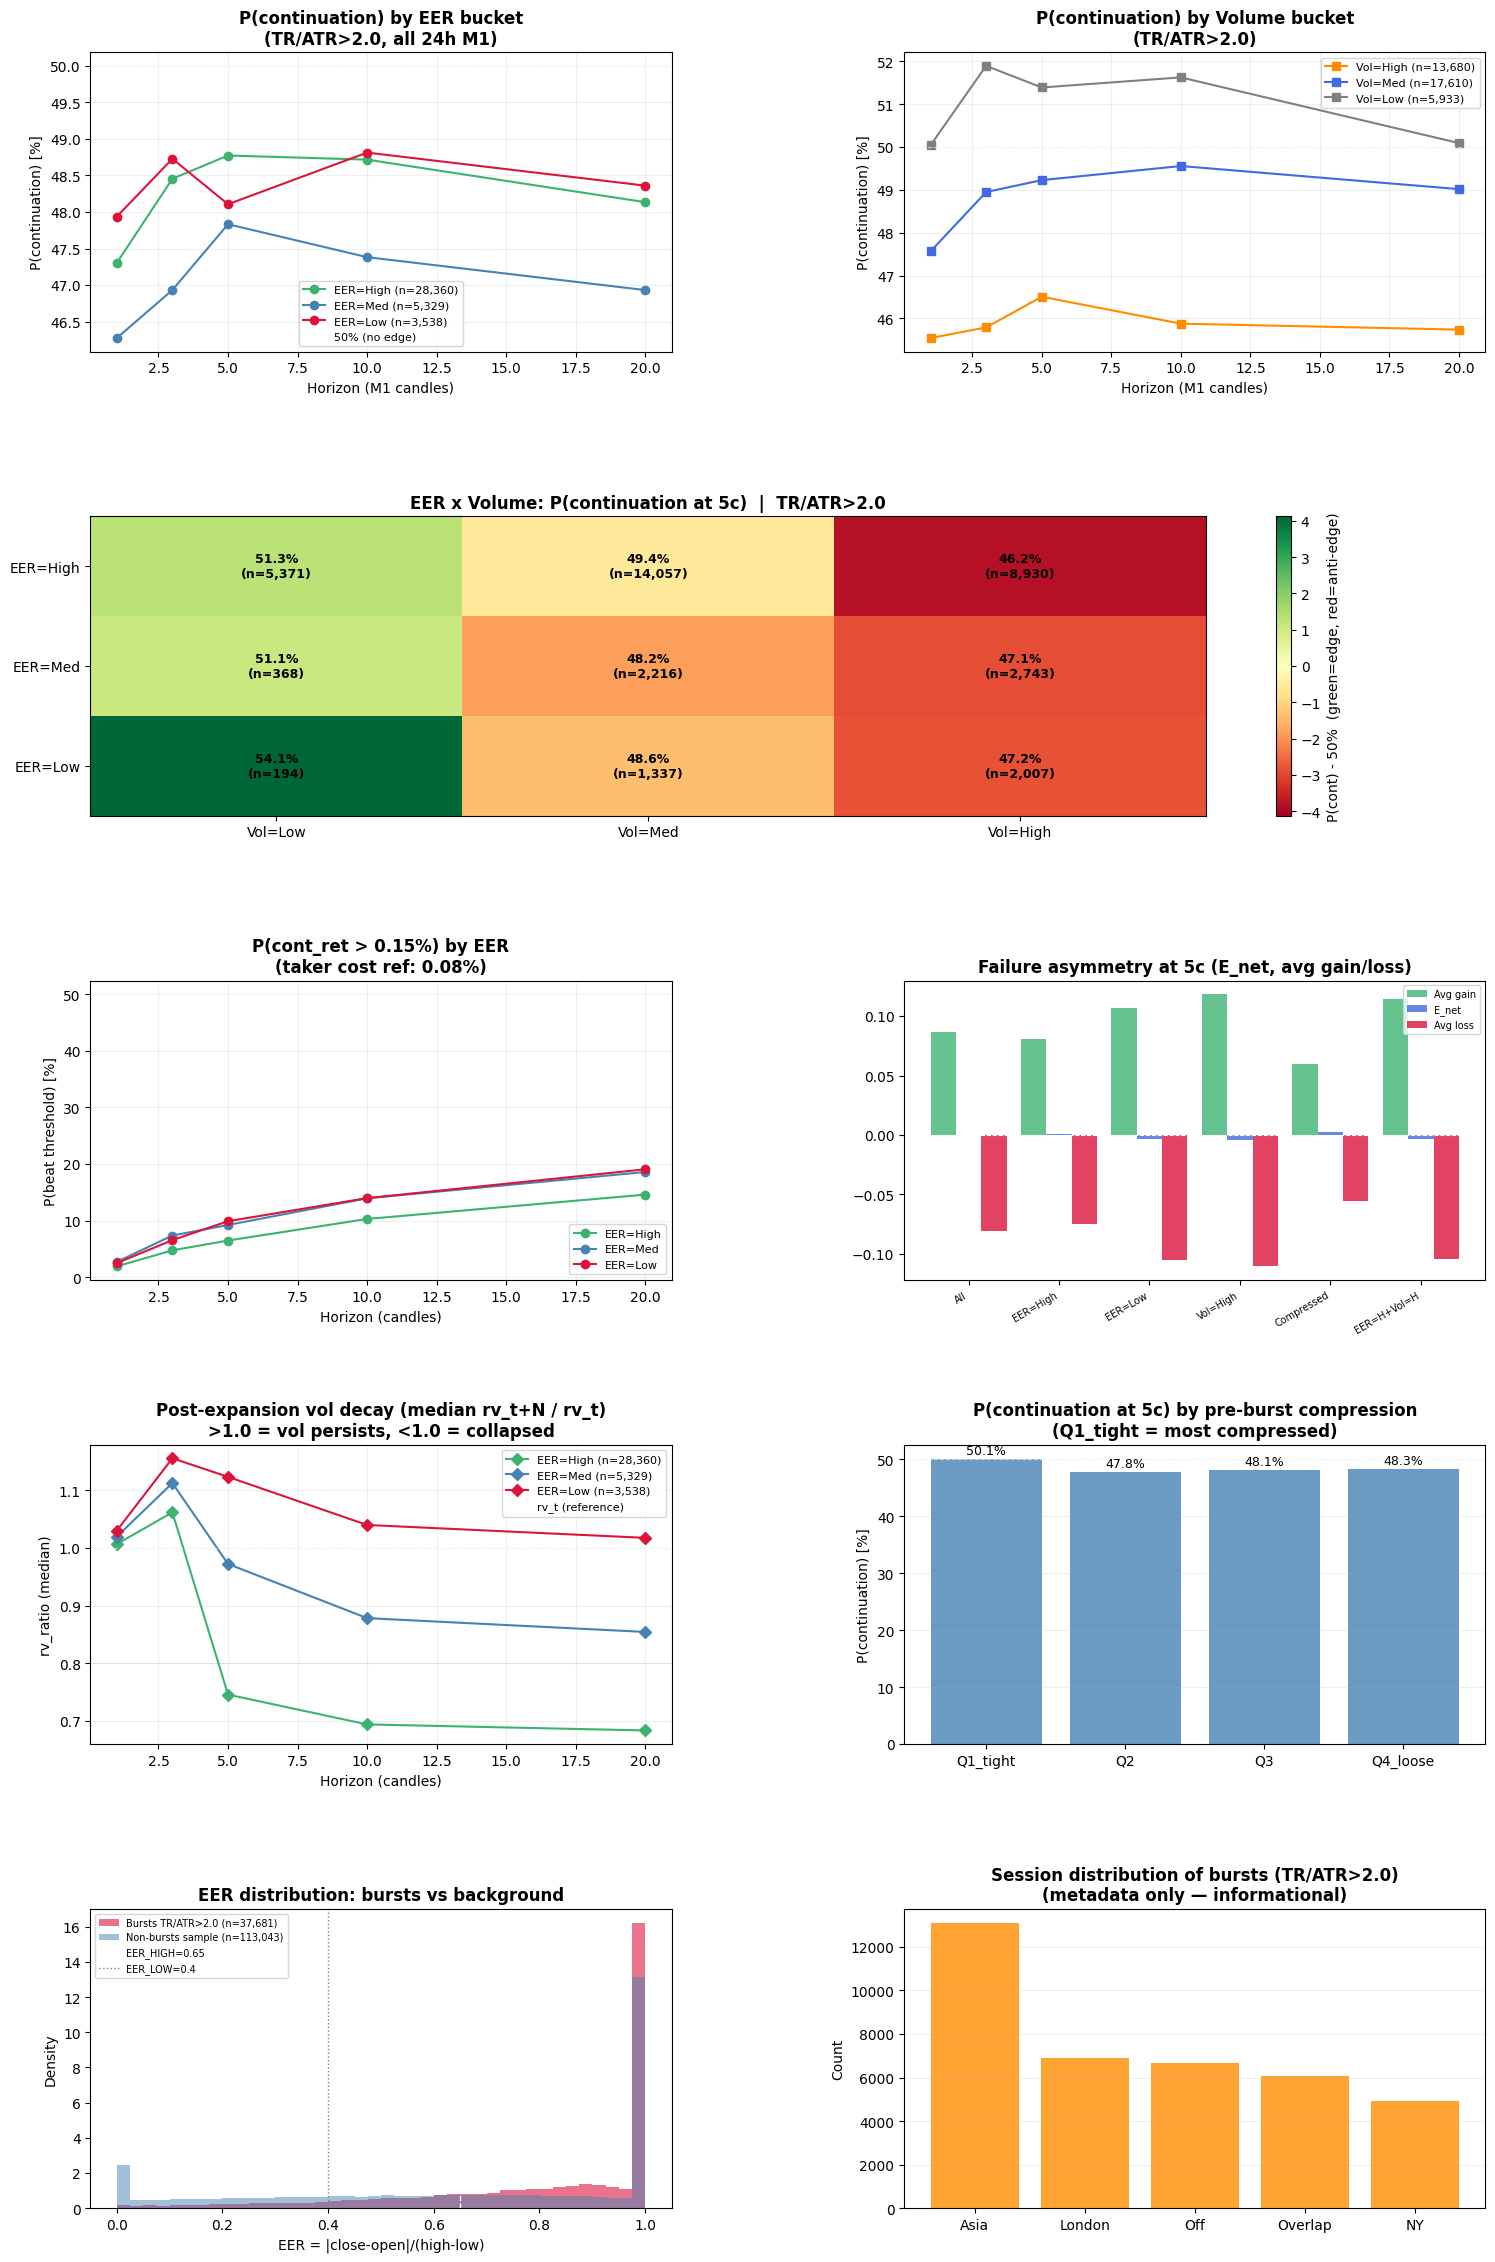

Saved: 07_visualizations.png
Cell 12 OK


In [12]:
# ── Visualizations ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 28))
gs  = gridspec.GridSpec(5, 2, figure=fig, hspace=0.55, wspace=0.40)

T_REF = 2.0
ev    = train[train['tr_atr_ratio'] > T_REF].dropna(
    subset=[f'cont_ret_{h}c' for h in FWD_HORIZONS]
)
c_eer = {'High': 'mediumseagreen', 'Med': 'steelblue', 'Low': 'crimson'}
c_vol = {'High': 'darkorange',     'Med': 'royalblue', 'Low': 'gray'}

# 1. P(continuation) by EER
ax1 = fig.add_subplot(gs[0, 0])
for eer_b in ['High', 'Med', 'Low']:
    sub = ev[ev['eer_bucket'] == eer_b]
    if len(sub) < 10: continue
    vals = [sub[f'cont_ret_{h}c'].dropna().gt(0).mean()*100 for h in FWD_HORIZONS]
    ax1.plot(FWD_HORIZONS, vals, marker='o', color=c_eer[eer_b], label=f'EER={eer_b} (n={len(sub):,})')
ax1.axhline(50, color='white', ls='--', lw=0.8, alpha=0.6, label='50% (no edge)')
ax1.set_title(f'P(continuation) by EER bucket\n(TR/ATR>{T_REF}, all 24h M1)', fontweight='bold')
ax1.set_xlabel('Horizon (M1 candles)'); ax1.set_ylabel('P(continuation) [%]')
ax1.legend(fontsize=8); ax1.grid(alpha=0.2)

# 2. P(continuation) by Volume
ax2 = fig.add_subplot(gs[0, 1])
for vol_b in ['High', 'Med', 'Low']:
    sub = ev[ev['vol_bucket'] == vol_b]
    if len(sub) < 10: continue
    vals = [sub[f'cont_ret_{h}c'].dropna().gt(0).mean()*100 for h in FWD_HORIZONS]
    ax2.plot(FWD_HORIZONS, vals, marker='s', color=c_vol[vol_b], label=f'Vol={vol_b} (n={len(sub):,})')
ax2.axhline(50, color='white', ls='--', lw=0.8, alpha=0.6)
ax2.set_title(f'P(continuation) by Volume bucket\n(TR/ATR>{T_REF})', fontweight='bold')
ax2.set_xlabel('Horizon (M1 candles)'); ax2.set_ylabel('P(continuation) [%]')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

# 3. EER x Volume heatmap (P(continuation at 5c))
ax3 = fig.add_subplot(gs[1, :])
EER_LABS = ['High', 'Med', 'Low']
VOL_LABS = ['Low', 'Med', 'High']
H_HEAT   = 5
matrix   = np.full((len(EER_LABS), len(VOL_LABS)), np.nan)
for i, eer_b in enumerate(EER_LABS):
    for j, vol_b in enumerate(VOL_LABS):
        sub = ev[(ev['eer_bucket']==eer_b) & (ev['vol_bucket']==vol_b)]
        if len(sub) >= 10:
            matrix[i, j] = sub[f'cont_ret_{H_HEAT}c'].dropna().gt(0).mean() * 100
vmax = max(abs(matrix[~np.isnan(matrix)] - 50).max(), 1.0)
im   = ax3.imshow(matrix - 50, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
ax3.set_xticks(range(len(VOL_LABS))); ax3.set_xticklabels([f'Vol={v}' for v in VOL_LABS], fontsize=10)
ax3.set_yticks(range(len(EER_LABS))); ax3.set_yticklabels([f'EER={e}' for e in EER_LABS], fontsize=10)
plt.colorbar(im, ax=ax3, label='P(cont) - 50%  (green=edge, red=anti-edge)')
for i in range(len(EER_LABS)):
    for j in range(len(VOL_LABS)):
        if not np.isnan(matrix[i, j]):
            sub = ev[(ev['eer_bucket']==EER_LABS[i]) & (ev['vol_bucket']==VOL_LABS[j])]
            ax3.text(j, i, f'{matrix[i,j]:.1f}%\n(n={len(sub):,})',
                     ha='center', va='center', fontsize=9, fontweight='bold')
ax3.set_title(f'EER x Volume: P(continuation at {H_HEAT}c)  |  TR/ATR>{T_REF}', fontweight='bold')

# 4. Tail persistence at 0.15% by EER
ax4 = fig.add_subplot(gs[2, 0])
tail_t = 0.0015
for eer_b in ['High', 'Med', 'Low']:
    sub = ev[ev['eer_bucket'] == eer_b]
    if len(sub) < 10: continue
    vals = [(sub[f'cont_ret_{h}c'].dropna() > tail_t).mean()*100 for h in FWD_HORIZONS]
    ax4.plot(FWD_HORIZONS, vals, marker='o', color=c_eer[eer_b], label=f'EER={eer_b}')
ax4.axhline(50, color='white', ls='--', lw=0.6, alpha=0.4)
ax4.set_title(f'P(cont_ret > {tail_t*100:.2f}%) by EER\n(taker cost ref: {COSTS_TOTAL*100:.2f}%)', fontweight='bold')
ax4.set_xlabel('Horizon (candles)'); ax4.set_ylabel('P(beat threshold) [%]')
ax4.legend(fontsize=8); ax4.grid(alpha=0.2)

# 5. E_net by group at 5c
ax5 = fig.add_subplot(gs[2, 1])
if len(adf) > 0:
    H_ASYM = 5
    x = np.arange(len(adf))
    w = 0.28
    ax5.bar(x - w,   [r[f'avg_gain_{H_ASYM}c'] for _, r in adf.iterrows()], w, color='mediumseagreen', alpha=0.8, label='Avg gain')
    ax5.bar(x,       [r[f'e_net_{H_ASYM}c']    for _, r in adf.iterrows()], w, color='royalblue',      alpha=0.8, label='E_net')
    ax5.bar(x + w,   [r[f'avg_loss_{H_ASYM}c'] for _, r in adf.iterrows()], w, color='crimson',        alpha=0.8, label='Avg loss')
    ax5.set_xticks(x); ax5.set_xticklabels(adf['label'].tolist(), rotation=30, ha='right', fontsize=7)
    ax5.axhline(0, color='white', ls='--', lw=0.8)
    ax5.set_title(f'Failure asymmetry at {H_ASYM}c (E_net, avg gain/loss)', fontweight='bold')
    ax5.legend(fontsize=7)

# 6. Volatility decay by EER
ax6 = fig.add_subplot(gs[3, 0])
ev_rv = train[train['tr_atr_ratio'] > T_REF].copy()
ev_rv_valid = ev_rv.dropna(subset=['rv5'] + [f'fwd_rv5_{h}c' for h in FWD_HORIZONS])
for eer_b in ['High', 'Med', 'Low']:
    sub = ev_rv_valid[ev_rv_valid['eer_bucket'] == eer_b]
    if len(sub) < 10: continue
    rv_t    = sub['rv5'].clip(lower=1e-10)
    ratios  = []
    for h in FWD_HORIZONS:
        ratio = (sub[f'fwd_rv5_{h}c'] / rv_t).dropna()
        ratios.append(ratio.median())
    ax6.plot(FWD_HORIZONS, ratios, marker='D', color=c_eer[eer_b], label=f'EER={eer_b} (n={len(sub):,})')
ax6.axhline(1.0, color='white', ls='--', lw=0.8, alpha=0.5, label='rv_t (reference)')
ax6.axhline(0.8, color='gray',  ls=':',  lw=0.6, alpha=0.4)
ax6.set_title('Post-expansion vol decay (median rv_t+N / rv_t)\n>1.0 = vol persists, <1.0 = collapsed', fontweight='bold')
ax6.set_xlabel('Horizon (candles)'); ax6.set_ylabel('rv_ratio (median)')
ax6.legend(fontsize=8); ax6.grid(alpha=0.2)

# 7. Compression quartile vs P(continuation at 5c)
ax7 = fig.add_subplot(gs[3, 1])
if 'compdf' in dir() and len(compdf) > 0 and 'p_cont_5c' in compdf.columns:
    bars = ax7.bar(compdf['comp_state'], compdf['p_cont_5c'], color='steelblue', alpha=0.8)
    ax7.axhline(50, color='white', ls='--', lw=0.8, alpha=0.6)
    for bar, val in zip(bars, compdf['p_cont_5c']):
        ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax7.set_title('P(continuation at 5c) by pre-burst compression\n(Q1_tight = most compressed)', fontweight='bold')
    ax7.set_ylabel('P(continuation) [%]'); ax7.grid(axis='y', alpha=0.2)

# 8. EER distribution in bursts vs background
ax8 = fig.add_subplot(gs[4, 0])
bursts_eer = train[train['tr_atr_ratio'] > T_REF]['eer'].dropna()
bg_eer     = train[train['tr_atr_ratio'] <= T_REF]['eer'].dropna()
bg_sample  = bg_eer.sample(min(len(bursts_eer)*3, len(bg_eer)), random_state=42)
ax8.hist(bursts_eer, bins=40, color='crimson',  alpha=0.6, density=True, label=f'Bursts TR/ATR>{T_REF} (n={len(bursts_eer):,})')
ax8.hist(bg_sample,  bins=40, color='steelblue', alpha=0.5, density=True, label=f'Non-bursts sample (n={len(bg_sample):,})')
ax8.axvline(EER_HIGH, color='white', ls='--', lw=1.0, label=f'EER_HIGH={EER_HIGH}')
ax8.axvline(EER_LOW,  color='gray',  ls=':',  lw=1.0, label=f'EER_LOW={EER_LOW}')
ax8.set_title('EER distribution: bursts vs background', fontweight='bold')
ax8.set_xlabel('EER = |close-open|/(high-low)'); ax8.set_ylabel('Density')
ax8.legend(fontsize=7)

# 9. Session distribution of bursts (metadata)
ax9 = fig.add_subplot(gs[4, 1])
sess_counts = train[train['tr_atr_ratio'] > T_REF]['session'].value_counts()
ax9.bar(sess_counts.index.astype(str), sess_counts.values, color='darkorange', alpha=0.8)
ax9.set_title(f'Session distribution of bursts (TR/ATR>{T_REF})\n(metadata only — informational)', fontweight='bold')
ax9.set_ylabel('Count'); ax9.grid(axis='y', alpha=0.2)

plt.savefig(OUTPUT_DIR / '07_visualizations.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 07_visualizations.png')
print('Cell 12 OK')

In [13]:
# ── Summary ────────────────────────────────────────────────────────────────────
SEP2 = '=' * 68
print(SEP2)
print('  EXP 07 — VOLATILITY EXPANSION ASYMMETRY STUDY SUMMARY')
print(f'  SPEC_HASH: {SPEC_HASH}')
print('  TRAIN ONLY — all 24h M1 candles')
print(SEP2)

T_REF = 2.0
ev = train[train['tr_atr_ratio'] > T_REF].dropna(
    subset=[f'cont_ret_{h}c' for h in FWD_HORIZONS]
)
best = ev[(ev['eer_bucket'] == 'High') & (ev['vol_bucket'] == 'High')]

def metric(label, val, width=48):
    print(f'  {label+":":<{width}} {val}')

print()
print('  OVERALL (TR/ATR > 2.0):')
metric('n_burst_events (train)', f'{len(ev):,}')
metric('P(continuation@1c) — all', f'{ev["cont_ret_1c"].gt(0).mean()*100:.1f}%')
metric('P(continuation@5c) — all', f'{ev["cont_ret_5c"].gt(0).mean()*100:.1f}%')
metric('Mean directional drift@5c — all', f'{ev["cont_ret_5c"].mean()*100:+.4f}%')
metric(f'P(drift > taker cost {COSTS_TOTAL*100:.3f}%)@5c — all',
       f'{(ev["cont_ret_5c"] > COSTS_TOTAL).mean()*100:.1f}%')

print()
print(f'  BEST CONDITIONAL BIN (EER=High + Vol=High, n={len(best):,}):')
if len(best) >= 10:
    metric('P(continuation@5c)', f'{best["cont_ret_5c"].gt(0).mean()*100:.1f}%')
    metric('Mean directional drift@5c', f'{best["cont_ret_5c"].mean()*100:+.4f}%')
    metric(f'P(drift > taker cost)@5c', f'{(best["cont_ret_5c"] > COSTS_TOTAL).mean()*100:.1f}%')
else:
    print('  (insufficient events in best bin)')

print()
print('  INTERPRETATION GUIDE:')
print()
print('  [GO → Exp 07b strategy design] if ALL of:')
print('    P(cont@5c) > 55% in at least one conditional bin')
print(f'    Mean drift@5c > {COSTS_TOTAL*100:.3f}% (taker costs) in that bin')
print('    E_net (Question D) > 0 in that bin')
print('    Vol persistence (Question E) stays elevated at 5c+ → momentum environment')
print()
print('  [NO-GO → family dead] if:')
print('    P(cont@5c) ≈ 50% across all conditioning')
print('    Mean drift << taker costs in all bins')
print('    E_net < 0 even in best bin')
print()
print('  [PARTIAL → requires deeper search] if:')
print('    Direction right (P(cont) > 50%) but magnitude insufficient for taker')
print('    → Consider maker-only strategy, or larger threshold to increase drift')
print()
print('  HARD EPISTEMOLOGICAL QUESTION (Bryan, S10):')
print('  If Exp 07 also fails to find magnitude: this project may be approaching')
print('  the limit of what retail taker execution can extract from BTC M1.')
print('  The real alpha may reside in: execution quality, inventory management,')
print('  market making, latency, cross-venue positioning, liquidation mechanics.')
print('  That conclusion is also a finding — and an honest one.')
print()
print('  DBCT NOTE:')
print('  TR/ATR uses no external dynamic benchmark. If edge is found here,')
print('  no decomposition analysis is required before proceeding to strategy design.')
print(SEP2)
print('Cell 13 OK — Exp 07 complete')

  EXP 07 — VOLATILITY EXPANSION ASYMMETRY STUDY SUMMARY
  SPEC_HASH: c4eea0bd7574
  TRAIN ONLY — all 24h M1 candles

  OVERALL (TR/ATR > 2.0):
  n_burst_events (train):                          37,227
  P(continuation@1c) — all:                        47.2%
  P(continuation@5c) — all:                        48.6%
  Mean directional drift@5c — all:                 +0.0002%
  P(drift > taker cost 0.080%)@5c — all:           15.9%

  BEST CONDITIONAL BIN (EER=High + Vol=High, n=8,930):
  P(continuation@5c):                              46.2%
  Mean directional drift@5c:                       -0.0033%
  P(drift > taker cost)@5c:                        19.2%

  INTERPRETATION GUIDE:

  [GO → Exp 07b strategy design] if ALL of:
    P(cont@5c) > 55% in at least one conditional bin
    Mean drift@5c > 0.080% (taker costs) in that bin
    E_net (Question D) > 0 in that bin
    Vol persistence (Question E) stays elevated at 5c+ → momentum environment

  [NO-GO → family dead] if:
    P(cont@5c) ≈